In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RAW = "../data/raw/42809099999_Kolkata.csv"

df = pd.read_csv(RAW, low_memory=False)

print("shape:", df.shape)
print("\ncolumns:")
print(df.columns.tolist())

shape: (19635, 39)

columns:
['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG', 'VIS', 'TMP', 'DEW', 'SLP', 'AA1', 'AY1', 'AY2', 'AZ1', 'AZ2', 'ED1', 'GA1', 'GA2', 'GA3', 'GA4', 'GA5', 'GE1', 'GF1', 'KA1', 'KA2', 'MA1', 'MD1', 'MW1', 'MW2', 'OC1', 'OD1', 'REM', 'EQD']


In [89]:
#df.head(10)
df[["STATION", "DATE", "REPORT_TYPE", "TMP", "DEW", "SLP"]].head(10)

,STATION,DATE,REPORT_TYPE,TMP,DEW,SLP
0,42809099999,2024-01-01T00:00:00,FM-12,"+0158,1","+0140,1","10165,1"
1,42809099999,2024-01-01T00:00:00,FM-15,"+0130,1","+0110,1","99999,9"
2,42809099999,2024-01-01T00:30:00,FM-15,"+0130,1","+0110,1","99999,9"
3,42809099999,2024-01-01T01:00:00,FM-15,"+0130,1","+0110,1","99999,9"
4,42809099999,2024-01-01T01:30:00,FM-15,"+0140,1","+0120,1","99999,9"
5,42809099999,2024-01-01T02:00:00,FM-15,"+0150,1","+0130,1","99999,9"
6,42809099999,2024-01-01T02:30:00,FM-15,"+0150,1","+0130,1","99999,9"
7,42809099999,2024-01-01T03:00:00,FM-12,"+0168,1","+0140,1","10187,1"
8,42809099999,2024-01-01T03:00:00,FM-15,"+0160,1","+0130,1","99999,9"
9,42809099999,2024-01-01T03:30:00,FM-15,"+0160,1","+0140,1","99999,9"


In [90]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19635 entries, 0 to 19634
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATION          19635 non-null  int64  
 1   DATE             19635 non-null  object 
 2   SOURCE           19635 non-null  int64  
 3   LATITUDE         19635 non-null  float64
 4   LONGITUDE        19635 non-null  float64
 5   ELEVATION        19635 non-null  float64
 6   NAME             19635 non-null  object 
 7   REPORT_TYPE      19635 non-null  object 
 8   CALL_SIGN        19635 non-null  int64  
 9   QUALITY_CONTROL  19635 non-null  object 
 10  WND              19635 non-null  object 
 11  CIG              19635 non-null  object 
 12  VIS              19635 non-null  object 
 13  TMP              19635 non-null  object 
 14  DEW              19635 non-null  object 
 15  SLP              19635 non-null  object 
 16  AA1              878 non-null    object 
 17  AY1         

,STATION,SOURCE,LATITUDE,LONGITUDE,ELEVATION,CALL_SIGN
count,1.963500e+04,19635.0,1.963500e+04,1.963500e+04,1.963500e+04,19635.0
mean,4.280910e+10,4.0,2.265474e+01,8.844672e+01,4.870000e+00,99999.0
std,0.000000e+00,0.0,3.552804e-15,2.842243e-14,8.882010e-16,0.0
min,4.280910e+10,4.0,2.265474e+01,8.844672e+01,4.870000e+00,99999.0
25%,4.280910e+10,4.0,2.265474e+01,8.844672e+01,4.870000e+00,99999.0
50%,4.280910e+10,4.0,2.265474e+01,8.844672e+01,4.870000e+00,99999.0
75%,4.280910e+10,4.0,2.265474e+01,8.844672e+01,4.870000e+00,99999.0
max,4.280910e+10,4.0,2.265474e+01,8.844672e+01,4.870000e+00,99999.0


In [91]:
def parse_isd(col, missing):
    """Split an ISD 'value,quality' field into a scaled float and its QC code."""
    parts = col.astype(str).str.split(",", expand=True)
    value = pd.to_numeric(parts[0], errors="coerce")
    value = value.where(value != missing) / 10.0
    qc = parts[1]
    return value, qc

d = pd.DataFrame()
d["time"]    = pd.to_datetime(df["DATE"])
d["station"] = df["STATION"].astype(str)
d["report"]  = df["REPORT_TYPE"].astype(str).str.strip()

d["temp_c"],  d["temp_qc"] = parse_isd(df["TMP"], 9999)
d["dew_c"],   d["dew_qc"]  = parse_isd(df["DEW"], 9999)
d["slp_hpa"], d["slp_qc"]  = parse_isd(df["SLP"], 99999)

d.head()

,time,station,report,temp_c,temp_qc,dew_c,dew_qc,slp_hpa,slp_qc
0,2024-01-01 00:00:00,42809099999,FM-12,15.8,1,14.0,1,1016.5,1
1,2024-01-01 00:00:00,42809099999,FM-15,13.0,1,11.0,1,NaN,9
2,2024-01-01 00:30:00,42809099999,FM-15,13.0,1,11.0,1,NaN,9
3,2024-01-01 01:00:00,42809099999,FM-15,13.0,1,11.0,1,NaN,9
4,2024-01-01 01:30:00,42809099999,FM-15,14.0,1,12.0,1,NaN,9


In [92]:
A, B = 17.625, 243.04

d["rh_pct"] = 100 * np.exp(
    (A * d["dew_c"]) / (B + d["dew_c"]) - (A * d["temp_c"]) / (B + d["temp_c"])
)

d["rh_pct"] = d["rh_pct"].clip(upper=100)

print(d[["temp_c", "dew_c", "rh_pct"]].describe())

             temp_c         dew_c        rh_pct
count  19631.000000  19630.000000  19629.000000
mean      27.138898     21.995619     75.580955
std        5.495140      5.772276     16.201139
min       10.000000      3.000000     18.229588
25%       24.000000     17.000000     66.301944
50%       28.000000     25.000000     79.195467
75%       31.000000     27.000000     88.837516
max       44.000000     30.000000    100.000000


In [93]:
cols = ["temp_c", "slp_hpa", "rh_pct"]

print("rows:", len(d))
print("time range:", d["time"].min(), "→", d["time"].max())
print("station id(s):", d["station"].unique())

print("\n--- missing counts ---")
print(d[cols].isna().sum())

print("\n--- missing percentage ---")
print((d[cols].isna().mean() * 100).round(2))

print("\n--- rows per report type ---")
print(d["report"].value_counts())

print("\n--- temperature quality codes ---")
print(d["temp_qc"].value_counts(dropna=False))

print("\n--- pressure quality codes ---")
print(d["slp_qc"].value_counts(dropna=False))

print("\n--- duplicate timestamps ---")
print(d["time"].duplicated().sum())

rows: 19635
time range: 2024-01-01 00:00:00 → 2024-12-31 23:30:00
station id(s): ['42809099999']

--- missing counts ---
temp_c         4
slp_hpa    16872
rh_pct         6
dtype: int64

--- missing percentage ---
temp_c      0.02
slp_hpa    85.93
rh_pct      0.03
dtype: float64

--- rows per report type ---
report
FM-15    16838
FM-12     2766
FM-16       31
Name: count, dtype: int64

--- temperature quality codes ---
temp_qc
1    19584
5       33
2       14
9        4
Name: count, dtype: int64

--- pressure quality codes ---
slp_qc
9    16872
1     2763
Name: count, dtype: int64

--- duplicate timestamps ---
2761


In [94]:
main_type = d["report"].value_counts().idxmax()
print("most common report type:", main_type)

p = d[d["report"] == main_type].copy()
p = p.sort_values("time").reset_index(drop=True)
p = p.drop_duplicates(subset="time", keep="first").reset_index(drop=True)

p = p[["time", "station", "temp_c", "temp_qc",
       "dew_c", "dew_qc", "slp_hpa", "slp_qc", "rh_pct"]]

print("rows after filtering:", len(p))
print(p.dtypes)
p.head()

most common report type: FM-15
rows after filtering: 16838
time       datetime64[ns]
station            object
temp_c            float64
temp_qc            object
dew_c             float64
dew_qc             object
slp_hpa           float64
slp_qc             object
rh_pct            float64
dtype: object


,time,station,temp_c,temp_qc,dew_c,dew_qc,slp_hpa,slp_qc,rh_pct
0,2024-01-01 00:00:00,42809099999,13.0,1,11.0,1,NaN,9,87.659299
1,2024-01-01 00:30:00,42809099999,13.0,1,11.0,1,NaN,9,87.659299
2,2024-01-01 01:00:00,42809099999,13.0,1,11.0,1,NaN,9,87.659299
3,2024-01-01 01:30:00,42809099999,14.0,1,12.0,1,NaN,9,87.749358
4,2024-01-01 02:00:00,42809099999,15.0,1,13.0,1,NaN,9,87.838459


## Coverage and Gaps


In [95]:
p["gap_hours"] = p["time"].diff().dt.total_seconds() / 3600

print("--- most common intervals (hours) ---")
print(p["gap_hours"].value_counts().head(10))

print("\n--- interval statistics ---")
print(p["gap_hours"].describe())

median_gap = p["gap_hours"].median()
print("\nnominal sampling interval: %.2f hours" % median_gap)

span_hours = (p["time"].max() - p["time"].min()).total_seconds() / 3600
expected = span_hours / median_gap
print("observations present : %d" % len(p))
print("observations expected: %d" % expected)
print("coverage             : %.1f%%" % (100 * len(p) / expected))

gaps = p.loc[p["gap_hours"] > 2 * median_gap, ["time", "gap_hours"]].copy()
gaps["gap_start"] = gaps["time"] - pd.to_timedelta(gaps["gap_hours"], unit="h")
gaps = gaps.rename(columns={"time": "resumed_at"})
print("\n--- missing-data blocks (%d found) ---" % len(gaps))
print(gaps.sort_values("gap_hours", ascending=False).head(15))

--- most common intervals (hours) ---
gap_hours
0.500000    16629
1.000000       38
1.500000       22
0.483333       21
0.016667       20
0.050000        9
0.450000        9
0.066667        8
0.466667        8
0.033333        8
Name: count, dtype: int64

--- interval statistics ---
count    16837.000000
mean         0.521678
std          1.242133
min          0.016667
25%          0.500000
50%          0.500000
75%          0.500000
max        120.500000
Name: gap_hours, dtype: float64

nominal sampling interval: 0.50 hours
observations present : 16838
observations expected: 17567
coverage             : 95.9%

--- missing-data blocks (42 found) ---
               resumed_at  gap_hours           gap_start
4148  2024-04-01 18:00:00      120.5 2024-03-27 17:30:00
14986 2024-11-21 22:00:00       96.5 2024-11-17 21:30:00
10362 2024-08-12 22:00:00       25.5 2024-08-11 20:30:00
15416 2024-12-01 22:00:00       24.5 2024-11-30 21:30:00
5516  2024-05-01 22:00:00       24.5 2024-04-30 21:30:00
4

In [96]:
frac = p["temp_c"].dropna().mod(1)
print("fractional parts of temperature values:")
print(frac.value_counts().head(10))
print("\ndistinct temperature values:", p["temp_c"].nunique())

fractional parts of temperature values:
temp_c
0.0    16837
Name: count, dtype: int64

distinct temperature values: 35


In [97]:
tenths = (p["temp_c"].dropna() * 10).round().mod(10)
print(tenths.value_counts())

temp_c
0.0    16837
Name: count, dtype: int64


In [98]:
def timeplot(x, y, title, ylabel, color, outfile):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(x, y, lw=0.5, color=color)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Date (UTC)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate(rotation=45)

    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()

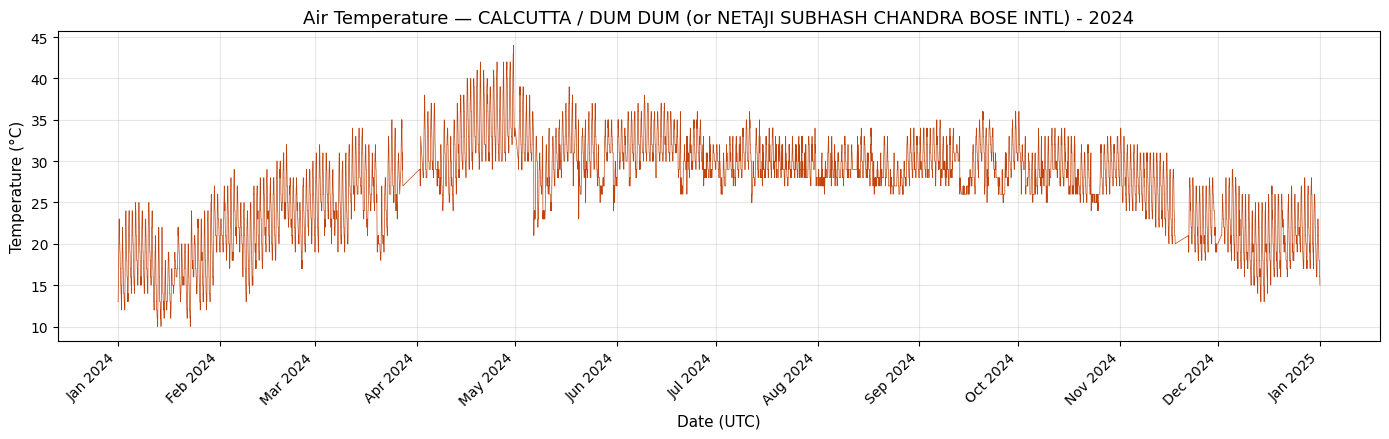

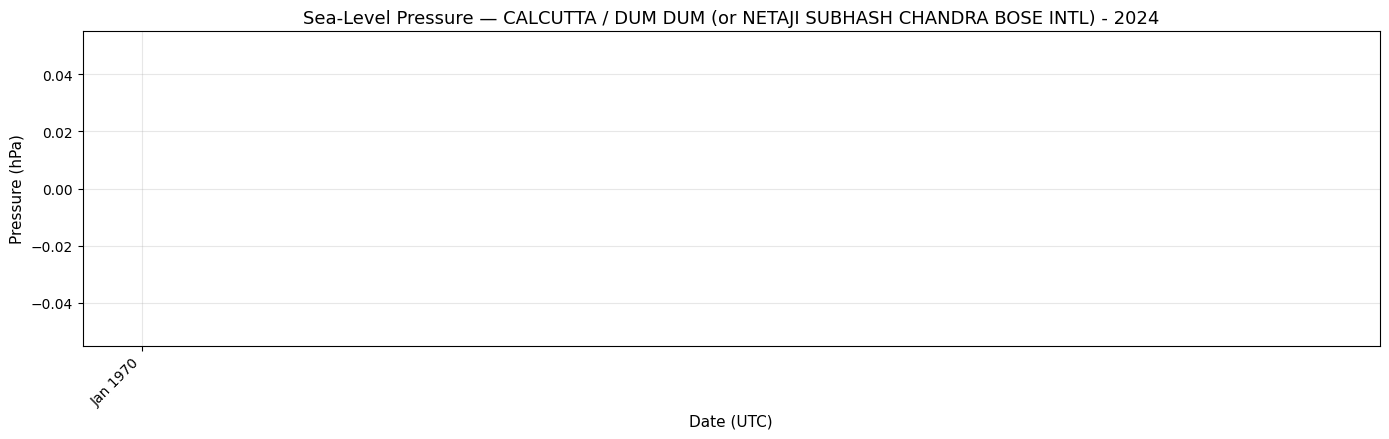

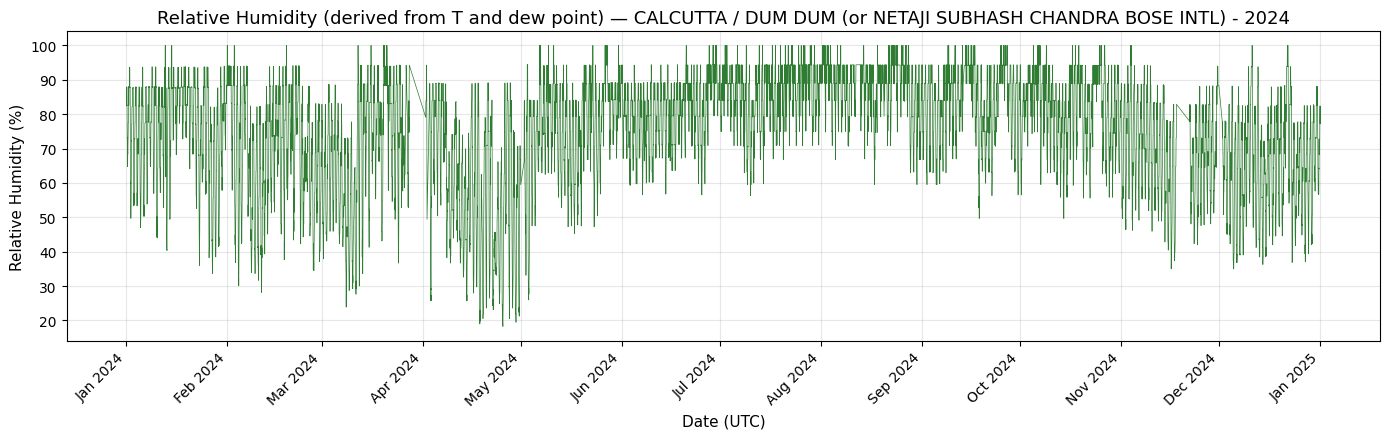

In [99]:
STATION_LABEL = "CALCUTTA / DUM DUM (or NETAJI SUBHASH CHANDRA BOSE INTL) - 2024"

timeplot(p["time"], p["temp_c"],
         "Air Temperature — " + STATION_LABEL,
         "Temperature (°C)", "#c1440e",
         "../figures/01_temperature_kolkata.png")

timeplot(p["time"], p["slp_hpa"],
         "Sea-Level Pressure — " + STATION_LABEL,
         "Pressure (hPa)", "#1f4e79",
         "../figures/02_pressure_kolkata.png")

timeplot(p["time"], p["rh_pct"],
         "Relative Humidity (derived from T and dew point) — " + STATION_LABEL,
         "Relative Humidity (%)", "#2e7d32",
         "../figures/03_humidity_kolkata.png")

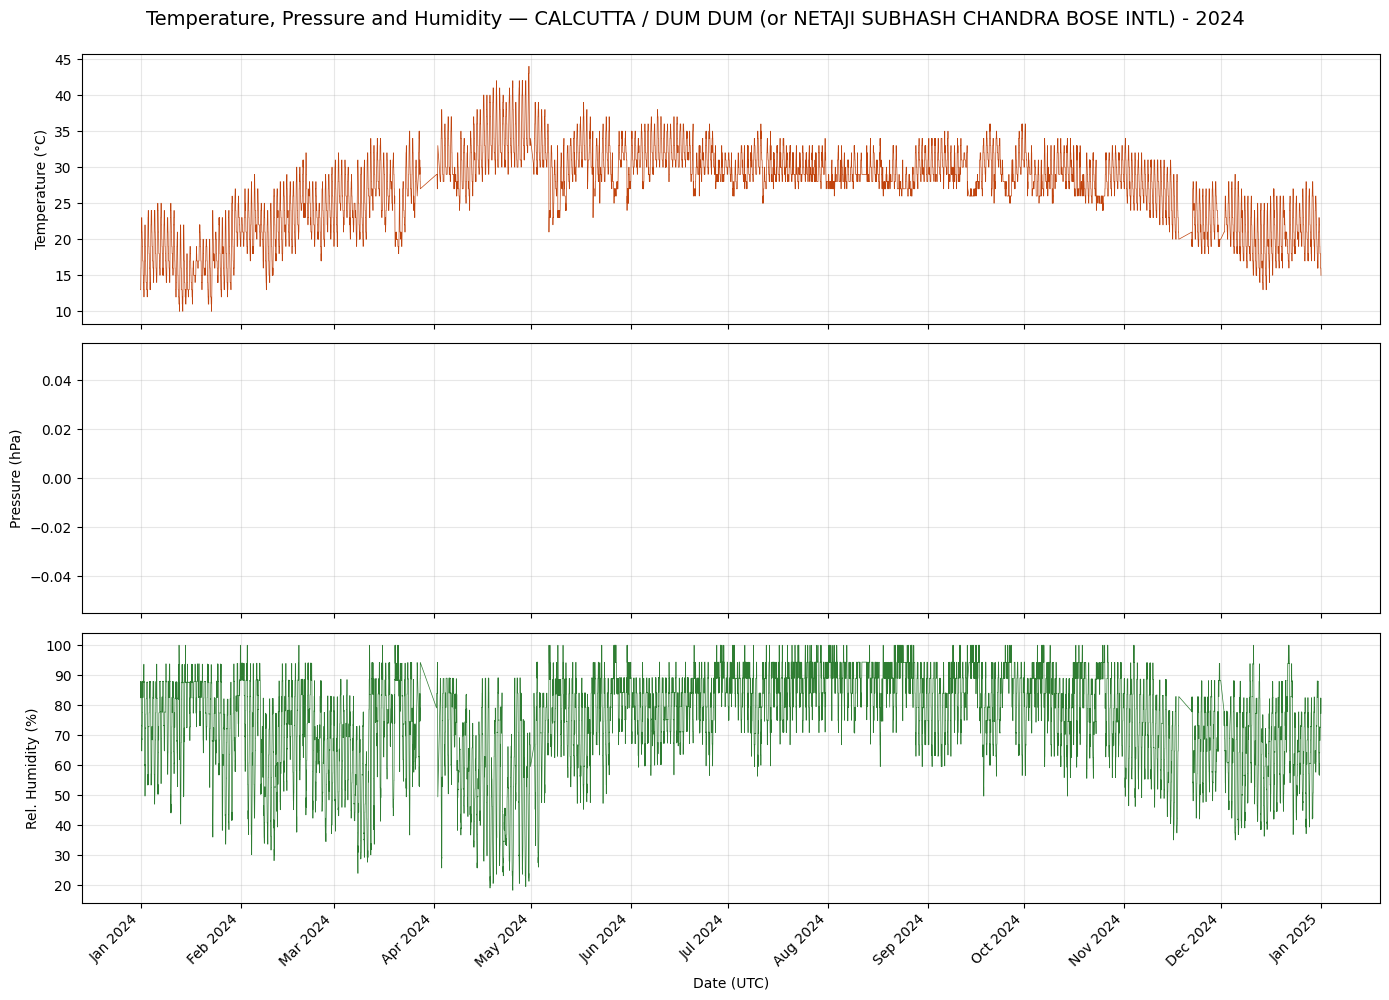

In [100]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax[0].plot(p["time"], p["temp_c"], lw=0.5, color="#c1440e")
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid(alpha=0.3)

ax[1].plot(p["time"], p["slp_hpa"], lw=0.5, color="#1f4e79")
ax[1].set_ylabel("Pressure (hPa)")
ax[1].grid(alpha=0.3)

ax[2].plot(p["time"], p["rh_pct"], lw=0.5, color="#2e7d32")
ax[2].set_ylabel("Rel. Humidity (%)")
ax[2].set_xlabel("Date (UTC)")
ax[2].grid(alpha=0.3)

ax[2].xaxis.set_major_locator(mdates.MonthLocator())
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=45)

fig.suptitle("Temperature, Pressure and Humidity — " + STATION_LABEL,
             fontsize=14, y=0.995)
fig.tight_layout()
fig.savefig("../figures/04_combined_kolkata.png", dpi=150, bbox_inches="tight")
plt.show()

In [101]:
cols = ["temp_c", "slp_hpa", "rh_pct"]

stats = p[cols].agg(["min", "max", "mean", "median", "std"]).T.round(2)
stats["missing_pct"] = (p[cols].isna().mean() * 100).round(2)
stats["n_valid"] = p[cols].notna().sum()

print(stats)
stats.to_csv("../data/processed/summary_stats_kolkata.csv")

           min    max   mean  median    std  missing_pct  n_valid
temp_c   10.00   44.0  27.14    28.0   5.50         0.01    16837
slp_hpa    NaN    NaN    NaN     NaN    NaN       100.00        0
rh_pct   18.23  100.0  75.53    79.2  16.14         0.01    16836


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [102]:
for c, label in [("temp_c", "Temperature"), ("slp_hpa", "Pressure"), ("rh_pct", "Humidity")]:
    p[c + "_step"] = p[c].diff()

    print("\n=== %s: 10 largest changes between consecutive readings ===" % label)
    top = p.reindex(p[c + "_step"].abs().sort_values(ascending=False).index).head(10)
    print(top[["time", c, c + "_step", "gap_hours"]].to_string(index=False))


=== Temperature: 10 largest changes between consecutive readings ===
               time  temp_c  temp_c_step  gap_hours
2024-05-20 07:00:00    23.0        -11.0        1.0
2024-05-06 14:30:00    22.0         -9.0        0.5
2024-05-09 08:30:00    23.0         -9.0        0.5
2024-09-13 07:30:00    26.0         -7.0        0.5
2024-05-30 19:30:00    24.0         -7.0        1.0
2024-09-21 15:00:00    25.0         -6.0        0.5
2024-12-18 14:30:00    20.0         -6.0        6.5
2024-07-27 07:30:00    28.0         -5.0        0.5
2024-10-23 07:00:00    25.0         -5.0        0.5
2024-09-09 08:30:00    28.0         -5.0        0.5

=== Pressure: 10 largest changes between consecutive readings ===
               time  slp_hpa  slp_hpa_step  gap_hours
2024-01-01 00:00:00      NaN           NaN        NaN
2024-01-01 00:30:00      NaN           NaN        0.5
2024-01-01 01:00:00      NaN           NaN        0.5
2024-01-01 01:30:00      NaN           NaN        0.5
2024-01-01 02:00:00  

In [103]:
def find_flat_runs(frame, col, min_len=8):
    s = frame[col]
    run_id = s.ne(s.shift()).cumsum()
    g = frame.assign(_run=run_id).groupby("_run")
    runs = g.agg(start=("time", "min"),
                 end=("time", "max"),
                 length=("time", "size"),
                 value=(col, "first"))
    runs = runs[(runs["length"] >= min_len) & runs["value"].notna()]
    return runs.sort_values("length", ascending=False)

for c, label in [("temp_c", "Temperature"), ("slp_hpa", "Pressure"), ("rh_pct", "Humidity")]:
    r = find_flat_runs(p, c, min_len=8)
    print("\n=== %s: constant runs of 8+ consecutive readings (%d found) ===" % (label, len(r)))
    print(r.head(10).to_string())


=== Temperature: constant runs of 8+ consecutive readings (391 found) ===
                   start                 end  length  value
_run                                                       
3733 2024-08-24 09:30:00 2024-08-25 03:00:00      36   27.0
3984 2024-09-14 16:00:00 2024-09-15 07:30:00      32   26.0
4112 2024-09-25 12:30:00 2024-09-26 03:30:00      31   26.0
4103 2024-09-24 09:00:00 2024-09-24 22:00:00      27   28.0
3094 2024-07-04 13:00:00 2024-07-05 01:30:00      26   29.0
4229 2024-10-05 14:00:00 2024-10-06 02:00:00      25   26.0
3715 2024-08-22 14:30:00 2024-08-23 02:00:00      24   27.0
3474 2024-07-31 15:00:00 2024-08-01 03:00:00      23   28.0
3583 2024-08-10 10:30:00 2024-08-10 21:30:00      23   29.0
3978 2024-09-13 20:00:00 2024-09-14 07:00:00      23   26.0

=== Pressure: constant runs of 8+ consecutive readings (0 found) ===
Empty DataFrame
Columns: [start, end, length, value]
Index: []

=== Humidity: constant runs of 8+ consecutive readings (218 found) ===


In [104]:
candidates = []

for c in cols:
    r = find_flat_runs(p, c, min_len=8)
    for _, row in r.head(5).iterrows():
        candidates.append({"variable": c, "type": "flat_run",
                           "start": row["start"], "end": row["end"],
                           "detail": "%d constant readings at %.1f" % (row["length"], row["value"])})

for _, row in gaps.sort_values("gap_hours", ascending=False).head(5).iterrows():
    candidates.append({"variable": "all", "type": "missing_block",
                       "start": row["gap_start"], "end": row["resumed_at"],
                       "detail": "%.1f hour gap" % row["gap_hours"]})

for c in cols:
    top = p.reindex(p[c + "_step"].abs().sort_values(ascending=False).index).head(3)
    for _, row in top.iterrows():
        candidates.append({"variable": c, "type": "step",
                           "start": row["time"], "end": row["time"],
                           "detail": "change of %.1f in %.1f h" % (row[c + "_step"], row["gap_hours"])})

cand = pd.DataFrame(candidates).sort_values("start").reset_index(drop=True)
cand.to_csv("../data/processed/candidate_periods_kolkata.csv", index=False)
print(cand.to_string())

   variable           type               start                 end                        detail
0   slp_hpa           step 2024-01-01 00:00:00 2024-01-01 00:00:00        change of nan in nan h
1   slp_hpa           step 2024-01-01 00:30:00 2024-01-01 00:30:00        change of nan in 0.5 h
2   slp_hpa           step 2024-01-01 01:00:00 2024-01-01 01:00:00        change of nan in 0.5 h
3    rh_pct           step 2024-01-13 02:00:00 2024-01-13 02:00:00      change of -31.7 in 0.5 h
4       all  missing_block 2024-03-27 17:30:00 2024-04-01 18:00:00                120.5 hour gap
5    rh_pct           step 2024-04-02 21:30:00 2024-04-02 21:30:00      change of 34.4 in 17.5 h
6       all  missing_block 2024-04-30 21:30:00 2024-05-01 22:00:00                 24.5 hour gap
7    rh_pct           step 2024-05-02 13:00:00 2024-05-02 13:00:00       change of 28.3 in 0.5 h
8    temp_c           step 2024-05-06 14:30:00 2024-05-06 14:30:00       change of -9.0 in 0.5 h
9    temp_c           step 202

In [105]:
p.to_csv("../data/processed/vidd_2023_clean_kolkata.csv", index=False)
print("saved", len(p), "rows")
print(p.columns.tolist())

saved 16838 rows
['time', 'station', 'temp_c', 'temp_qc', 'dew_c', 'dew_qc', 'slp_hpa', 'slp_qc', 'rh_pct', 'gap_hours', 'temp_c_step', 'slp_hpa_step', 'rh_pct_step']
